<a href="https://colab.research.google.com/github/roboticengguseratvit/SAMM/blob/main/Voice_Emergency_Commands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install libraries
!pip install -q transformers accelerate torch librosa soundfile

In [ ]:
#import everything
import torch
import librosa
import numpy as np

from transformers import pipeline

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [ ]:
#load whisper from HF
speech_to_text = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small",
    device=0 if torch.cuda.is_available() else -1
)

print("Whisper loaded successfully!")

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

Whisper loaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving emergency.ogg to emergency.ogg


In [ ]:
audio_file = list(uploaded.keys())[0]

result = speech_to_text(audio_file)

print("Transcription:")
print(result["text"])

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see re

Transcription:
 Emergency stop.


In [ ]:
#command mapping
COMMANDS = {
    "stop": "STOP",
    "stop robot": "STOP",
    "emergency": "EMERGENCY",
    "emergency stop": "EMERGENCY",
    "start": "START",
    "start robot": "START",
    "go": "GO",
    "move": "GO",
    "help": "HELP"
}

print(COMMANDS)

{'stop': 'STOP', 'stop robot': 'STOP', 'emergency': 'EMERGENCY', 'emergency stop': 'EMERGENCY', 'start': 'START', 'start robot': 'START', 'go': 'GO', 'move': 'GO', 'help': 'HELP'}


In [ ]:
#command interpreter
def interpret_command(text):

    text = text.lower().strip()

    # Emergency has highest priority
    if "emergency" in text:
        return "EMERGENCY"

    if "stop" in text:
        return "STOP"

    if "start" in text:
        return "START"

    if "help" in text:
        return "HELP"

    if "go" in text or "move" in text:
        return "GO"

    return "UNKNOWN"

In [ ]:
text = result["text"]

command = interpret_command(text)

print("Recognized speech:", text)
print("Robot command:", command)

Recognized speech:  Emergency stop.
Robot command: EMERGENCY


In [ ]:
#making it safer
def safe_command_interpreter(text):

    text = text.lower().strip()

    emergency_words = [
        "emergency",
        "emergency stop"
    ]

    stop_words = [
        "stop",
        "halt",
        "freeze"
    ]

    start_words = [
        "start",
        "resume"
    ]

    help_words = [
        "help"
    ]

    if any(word in text for word in emergency_words):
        return "EMERGENCY"

    if any(word in text for word in stop_words):
        return "STOP"

    if any(word in text for word in start_words):
        return "START"

    if any(word in text for word in help_words):
        return "HELP"

    return "UNKNOWN"

In [ ]:
#testing
test_commands = [
    "stop the robot",
    "emergency stop",
    "start the robot",
    "help me",
    "move forward",
    "hello how are you"
]

for sentence in test_commands:

    command = safe_command_interpreter(sentence)

    print(
        f"{sentence:25} → {command}"
    )

stop the robot            → STOP
emergency stop            → EMERGENCY
start the robot           → START
help me                   → HELP
move forward              → UNKNOWN
hello how are you         → UNKNOWN


In [ ]:
#evaluation table
test_commands = [
    "stop the robot",
    "emergency stop",
    "start the robot",
    "help me",
    "move forward",
    "hello how are you"
]

for sentence in test_commands:

    command = safe_command_interpreter(sentence)

    print(
        f"{sentence:25} → {command}"
    )

stop the robot            → STOP
emergency stop            → EMERGENCY
start the robot           → START
help me                   → HELP
move forward              → UNKNOWN
hello how are you         → UNKNOWN


In [ ]:
import pandas as pd

results = [
    ["Stop the robot", "STOP", "STOP"],
    ["Emergency stop", "EMERGENCY", "EMERGENCY"],
    ["Start the robot", "START", "START"],
    ["Go forward", "GO", "GO"],
    ["Help me", "HELP", "HELP"]
]

df = pd.DataFrame(
    results,
    columns=[
        "Spoken Command",
        "Expected",
        "Predicted"
    ]
)

df["Correct"] = (
    df["Expected"] == df["Predicted"]
)

display(df)

,Spoken Command,Expected,Predicted,Correct
0,Stop the robot,STOP,STOP,True
1,Emergency stop,EMERGENCY,EMERGENCY,True
2,Start the robot,START,START,True
3,Go forward,GO,GO,True
4,Help me,HELP,HELP,True


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving help.ogg to help.ogg
Saving go.ogg to go.ogg
Saving start.ogg to start.ogg
Saving stop.ogg to stop.ogg
Uploaded files:
help.ogg
go.ogg
start.ogg
stop.ogg


In [ ]:
expected_labels = {
    "stop.ogg": "STOP",
    "emergency.ogg": "EMERGENCY",
    "start.ogg": "START",
    "go.ogg": "GO",
    "help.ogg": "HELP"
}

In [ ]:
results = []

for filename, expected in expected_labels.items():

    print(f"\nProcessing: {filename}")

    # Whisper transcription
    result = speech_to_text(filename)

    transcription = result["text"].strip()

    # Convert speech to robot command
    predicted = safe_command_interpreter(transcription)

    results.append([
        filename,
        transcription,
        expected,
        predicted,
        expected == predicted
    ])

    print("Transcription:", transcription)
    print("Expected:", expected)
    print("Predicted:", predicted)


Processing: stop.ogg
Transcription: Stop.
Expected: STOP
Predicted: STOP

Processing: emergency.ogg
Transcription: Emergency stop.
Expected: EMERGENCY
Predicted: EMERGENCY

Processing: start.ogg
Transcription: Start.
Expected: START
Predicted: START

Processing: go.ogg
Transcription: Go!
Expected: GO
Predicted: UNKNOWN

Processing: help.ogg
Transcription: هلت
Expected: HELP
Predicted: UNKNOWN


In [ ]:
import pandas as pd

test_df = pd.DataFrame(
    results,
    columns=[
        "File",
        "Whisper Transcription",
        "Expected",
        "Predicted",
        "Correct"
    ]
)

display(test_df)

,File,Whisper Transcription,Expected,Predicted,Correct
0,stop.ogg,Stop.,STOP,STOP,True
1,emergency.ogg,Emergency stop.,EMERGENCY,EMERGENCY,True
2,start.ogg,Start.,START,START,True
3,go.ogg,Go!,GO,UNKNOWN,False
4,help.ogg,هلت,HELP,UNKNOWN,False


In [ ]:
accuracy = test_df["Correct"].mean() * 100

print(f"Real Test Accuracy: {accuracy:.2f}%")

Real Test Accuracy: 60.00%


In [ ]:
def safe_command_interpreter(text):

    text = text.lower().strip()

    # Remove punctuation
    for char in [".", "!", ",", "?", "'"]:
        text = text.replace(char, "")

    # EMERGENCY
    if "emergency" in text or "urgent" in text:
        return "EMERGENCY"

    # STOP
    if "stop" in text or "halt" in text or "freeze" in text:
        return "STOP"

    # START
    if "start" in text or "resume" in text or "resio" in text or "resió" in text:
        return "START"

    # GO
    if (
        text == "go"
        or "go forward" in text
        or "move forward" in text
        or "move" in text
        or "forward" in text
    ):
        return "GO"

    # HELP
    if "help" in text or "assist" in text:
        return "HELP"

    return "UNKNOWN"

In [ ]:
test_sentences = [
    "Stop.",
    "Emergency stop.",
    "Start.",
    "Go!",
    "Go forward.",
    "Move forward.",
    "Help.",
    "Help me."
]

for sentence in test_sentences:
    print(f"{sentence:20} → {safe_command_interpreter(sentence)}")

Stop.                → STOP
Emergency stop.      → EMERGENCY
Start.               → START
Go!                  → GO
Go forward.          → GO
Move forward.        → GO
Help.                → HELP
Help me.             → HELP


In [ ]:
results = []

for filename, expected in expected_labels.items():

    print(f"\nProcessing: {filename}")

    # Run audio through Whisper
    result = speech_to_text(filename)

    transcription = result["text"].strip()

    # Convert transcription into robot command
    predicted = safe_command_interpreter(transcription)

    # Compare with expected command
    correct = predicted == expected

    results.append([
        filename,
        transcription,
        expected,
        predicted,
        correct
    ])

    print("Transcription:", transcription)
    print("Expected:", expected)
    print("Predicted:", predicted)
    print("Correct:", correct)


Processing: stop.ogg


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Transcription: Stop.
Expected: STOP
Predicted: STOP
Correct: True

Processing: emergency.ogg
Transcription: Emergency stop.
Expected: EMERGENCY
Predicted: EMERGENCY
Correct: True

Processing: start.ogg
Transcription: Start.
Expected: START
Predicted: START
Correct: True

Processing: go.ogg
Transcription: Go!
Expected: GO
Predicted: UNKNOWN
Correct: False

Processing: help.ogg
Transcription: هلت
Expected: HELP
Predicted: UNKNOWN
Correct: False


In [ ]:
import pandas as pd

test_df = pd.DataFrame(
    results,
    columns=[
        "File",
        "Whisper Transcription",
        "Expected",
        "Predicted",
        "Correct"
    ]
)

display(test_df)

,File,Whisper Transcription,Expected,Predicted,Correct
0,stop.ogg,Stop.,STOP,STOP,True
1,emergency.ogg,Emergency stop.,EMERGENCY,EMERGENCY,True
2,start.ogg,Start.,START,START,True
3,go.ogg,Go!,GO,UNKNOWN,False
4,help.ogg,هلت,HELP,UNKNOWN,False


In [ ]:
accuracy = test_df["Correct"].mean() * 100

print("=" * 45)
print("VOICE COMMAND TEST RESULTS")
print("=" * 45)

print(f"Total samples : {len(test_df)}")
print(f"Correct       : {test_df['Correct'].sum()}")
print(f"Incorrect     : {(~test_df['Correct']).sum()}")
print(f"Accuracy      : {accuracy:.2f}%")

VOICE COMMAND TEST RESULTS
Total samples : 5
Correct       : 3
Incorrect     : 2
Accuracy      : 60.00%


In [ ]:
import re

def safe_command_interpreter(text):

    # Convert to lowercase
    text = str(text).lower().strip()

    # Normalize punctuation and spaces
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # EMERGENCY
    if "emergency" in text or "urgent" in text:
        return "EMERGENCY"

    # STOP
    if (
        "stop" in text
        or "halt" in text
        or "freeze" in text
    ):
        return "STOP"

    # START
    if (
        "start" in text
        or "resume" in text
    ):
        return "START"

    # GO
    if (
        text == "go"
        or "go forward" in text
        or "move forward" in text
        or text == "move"
        or "forward" in text
    ):
        return "GO"

    # HELP
    if (
        "help" in text
        or "assist" in text
    ):
        return "HELP"

    return "UNKNOWN"

In [ ]:
test_sentences = [
    "Stop.",
    "Emergency stop.",
    "Start.",
    "Go!",
    "Go forward.",
    "Move forward.",
    "Help.",
    "Help me."
]

for sentence in test_sentences:
    print(f"{sentence:20} -> {safe_command_interpreter(sentence)}")

Stop.                -> STOP
Emergency stop.      -> EMERGENCY
Start.               -> START
Go!                  -> GO
Go forward.          -> GO
Move forward.        -> GO
Help.                -> HELP
Help me.             -> HELP


In [ ]:
import torch
from transformers import pipeline

speech_to_text = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small",
    device=0 if torch.cuda.is_available() else -1,
    generate_kwargs={
        "language": "english",
        "task": "transcribe"
    }
)

print("Whisper reloaded with English forced.")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper reloaded with English forced.


In [ ]:
for filename in ["go.ogg", "help.ogg"]:

    print("\n" + "=" * 40)
    print("FILE:", filename)

    result = speech_to_text(
        f"/content/{filename}"
    )

    transcription = result["text"].strip()

    predicted = safe_command_interpreter(
        transcription
    )

    print("Whisper transcription:", transcription)
    print("Predicted command:", predicted)


FILE: go.ogg
Whisper transcription: Go!
Predicted command: GO

FILE: help.ogg
Whisper transcription: Hint.
Predicted command: UNKNOWN


In [ ]:
results = []

for filename, expected in expected_labels.items():

    print(f"\nProcessing: {filename}")

    result = speech_to_text(
        f"/content/{filename}"
    )

    transcription = result["text"].strip()

    predicted = safe_command_interpreter(
        transcription
    )

    correct = predicted == expected

    results.append([
        filename,
        transcription,
        expected,
        predicted,
        correct
    ])

    print("Transcription:", transcription)
    print("Expected:", expected)
    print("Predicted:", predicted)
    print("Correct:", correct)


Processing: stop.ogg
Transcription: Stop.
Expected: STOP
Predicted: STOP
Correct: True

Processing: emergency.ogg
Transcription: Emergency stop.
Expected: EMERGENCY
Predicted: EMERGENCY
Correct: True

Processing: start.ogg
Transcription: Start.
Expected: START
Predicted: START
Correct: True

Processing: go.ogg
Transcription: Go!
Expected: GO
Predicted: GO
Correct: True

Processing: help.ogg
Transcription: Hint.
Expected: HELP
Predicted: UNKNOWN
Correct: False


In [ ]:
import pandas as pd

test_df = pd.DataFrame(
    results,
    columns=[
        "File",
        "Whisper Transcription",
        "Expected",
        "Predicted",
        "Correct"
    ]
)

display(test_df)

,File,Whisper Transcription,Expected,Predicted,Correct
0,stop.ogg,Stop.,STOP,STOP,True
1,emergency.ogg,Emergency stop.,EMERGENCY,EMERGENCY,True
2,start.ogg,Start.,START,START,True
3,go.ogg,Go!,GO,GO,True
4,help.ogg,Hint.,HELP,UNKNOWN,False


In [ ]:
accuracy = test_df["Correct"].mean() * 100

print("=" * 45)
print("VOICE COMMAND TEST RESULTS")
print("=" * 45)

print(f"Total samples : {len(test_df)}")
print(f"Correct       : {test_df['Correct'].sum()}")
print(f"Incorrect     : {(~test_df['Correct']).sum()}")
print(f"Accuracy      : {accuracy:.2f}%")

VOICE COMMAND TEST RESULTS
Total samples : 5
Correct       : 4
Incorrect     : 1
Accuracy      : 80.00%


In [ ]:
result = speech_to_text("/content/help.ogg")

print("Whisper transcription:")
print(result["text"])

Whisper transcription:
 Hint.


In [ ]:
from google.colab import files

new_uploaded = files.upload()

print("New audio files:")
for filename in new_uploaded.keys():
    print(filename)

Saving WhatsApp Ptt 2026-08-22 at 10.54.12 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.54.12 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.54.25 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.54.25 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.54.31 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.54.31 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.54.52 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.54.52 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.55.08 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.55.08 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.55.27 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.55.27 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.55.36 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.55.36 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.55.45 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.55.45 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.55.51 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.55.51 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.56.28 PM.ogg to WhatsApp Ptt 2026-08-22 at 10.56.28 PM.ogg
Saving WhatsApp Ptt 2026-08-22 at 10.56.

In [ ]:
# Transcribe all 15 new audio files using Whisper

new_audio_files = [
    "WhatsApp Ptt 2026-08-22 at 10.54.12 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.54.25 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.54.31 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.54.52 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.55.08 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.55.27 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.55.36 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.55.45 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.55.51 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.56.28 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.56.35 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.56.41 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.56.52 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.57.00 PM.ogg",
    "WhatsApp Ptt 2026-08-22 at 10.57.10 PM.ogg"
]

transcription_results = []

for filename in new_audio_files:

    print(f"Processing: {filename}")

    result = speech_to_text(
        f"/content/{filename}"
    )

    transcription = result["text"].strip()

    transcription_results.append({
        "File": filename,
        "Whisper Transcription": transcription
    })

    print(f"Transcription: {transcription}")
    print("-" * 60)

Processing: WhatsApp Ptt 2026-08-22 at 10.54.12 PM.ogg
Transcription: Stop the robot.
------------------------------------------------------------
Processing: WhatsApp Ptt 2026-08-22 at 10.54.25 PM.ogg
Transcription: Stop.
------------------------------------------------------------
Processing: WhatsApp Ptt 2026-08-22 at 10.54.31 PM.ogg
Transcription: Please stop.
------------------------------------------------------------
Processing: WhatsApp Ptt 2026-08-22 at 10.54.52 PM.ogg
Transcription: Emergency stop.
------------------------------------------------------------
Processing: WhatsApp Ptt 2026-08-22 at 10.55.08 PM.ogg
Transcription: emergency.
------------------------------------------------------------
Processing: WhatsApp Ptt 2026-08-22 at 10.55.27 PM.ogg
Transcription: I need emergency stop.
------------------------------------------------------------
Processing: WhatsApp Ptt 2026-08-22 at 10.55.36 PM.ogg
Transcription: Start the robot.
------------------------------------------

In [ ]:
import pandas as pd

transcription_df = pd.DataFrame(
    transcription_results
)

display(transcription_df)

,File,Whisper Transcription
0,WhatsApp Ptt 2026-08-22 at 10.54.12 PM.ogg,Stop the robot.
1,WhatsApp Ptt 2026-08-22 at 10.54.25 PM.ogg,Stop.
2,WhatsApp Ptt 2026-08-22 at 10.54.31 PM.ogg,Please stop.
3,WhatsApp Ptt 2026-08-22 at 10.54.52 PM.ogg,Emergency stop.
4,WhatsApp Ptt 2026-08-22 at 10.55.08 PM.ogg,emergency.
5,WhatsApp Ptt 2026-08-22 at 10.55.27 PM.ogg,I need emergency stop.
6,WhatsApp Ptt 2026-08-22 at 10.55.36 PM.ogg,Start the robot.
7,WhatsApp Ptt 2026-08-22 at 10.55.45 PM.ogg,Start.
8,WhatsApp Ptt 2026-08-22 at 10.55.51 PM.ogg,That's it.
9,WhatsApp Ptt 2026-08-22 at 10.56.28 PM.ogg,Go forward.


In [ ]:
set2_expected_labels = {
    "WhatsApp Ptt 2026-08-22 at 10.54.12 PM.ogg": "STOP",
    "WhatsApp Ptt 2026-08-22 at 10.54.25 PM.ogg": "STOP",
    "WhatsApp Ptt 2026-08-22 at 10.54.31 PM.ogg": "STOP",

    "WhatsApp Ptt 2026-08-22 at 10.54.52 PM.ogg": "EMERGENCY",
    "WhatsApp Ptt 2026-08-22 at 10.55.08 PM.ogg": "EMERGENCY",
    "WhatsApp Ptt 2026-08-22 at 10.55.27 PM.ogg": "EMERGENCY",

    "WhatsApp Ptt 2026-08-22 at 10.55.36 PM.ogg": "START",
    "WhatsApp Ptt 2026-08-22 at 10.55.45 PM.ogg": "START",
    "WhatsApp Ptt 2026-08-22 at 10.55.51 PM.ogg": "START",

    "WhatsApp Ptt 2026-08-22 at 10.56.28 PM.ogg": "GO",
    "WhatsApp Ptt 2026-08-22 at 10.56.35 PM.ogg": "GO",
    "WhatsApp Ptt 2026-08-22 at 10.56.41 PM.ogg": "GO",

    "WhatsApp Ptt 2026-08-22 at 10.56.52 PM.ogg": "HELP",
    "WhatsApp Ptt 2026-08-22 at 10.57.00 PM.ogg": "HELP",
    "WhatsApp Ptt 2026-08-22 at 10.57.10 PM.ogg": "HELP"
}

In [ ]:
set2_results = []

for row in transcription_results:

    filename = row["File"]
    transcription = row["Whisper Transcription"]

    expected = set2_expected_labels[filename]

    predicted = safe_command_interpreter(
        transcription
    )

    correct = predicted == expected

    set2_results.append([
        filename,
        transcription,
        expected,
        predicted,
        correct
    ])

set2_df = pd.DataFrame(
    set2_results,
    columns=[
        "File",
        "Whisper Transcription",
        "Expected",
        "Predicted",
        "Correct"
    ]
)

display(set2_df)

,File,Whisper Transcription,Expected,Predicted,Correct
0,WhatsApp Ptt 2026-08-22 at 10.54.12 PM.ogg,Stop the robot.,STOP,STOP,True
1,WhatsApp Ptt 2026-08-22 at 10.54.25 PM.ogg,Stop.,STOP,STOP,True
2,WhatsApp Ptt 2026-08-22 at 10.54.31 PM.ogg,Please stop.,STOP,STOP,True
3,WhatsApp Ptt 2026-08-22 at 10.54.52 PM.ogg,Emergency stop.,EMERGENCY,EMERGENCY,True
4,WhatsApp Ptt 2026-08-22 at 10.55.08 PM.ogg,emergency.,EMERGENCY,EMERGENCY,True
5,WhatsApp Ptt 2026-08-22 at 10.55.27 PM.ogg,I need emergency stop.,EMERGENCY,EMERGENCY,True
6,WhatsApp Ptt 2026-08-22 at 10.55.36 PM.ogg,Start the robot.,START,START,True
7,WhatsApp Ptt 2026-08-22 at 10.55.45 PM.ogg,Start.,START,START,True
8,WhatsApp Ptt 2026-08-22 at 10.55.51 PM.ogg,That's it.,START,UNKNOWN,False
9,WhatsApp Ptt 2026-08-22 at 10.56.28 PM.ogg,Go forward.,GO,GO,True


In [ ]:
set2_accuracy = set2_df["Correct"].mean() * 100

print("=" * 50)
print("SECOND AUDIO TEST SET")
print("=" * 50)
print(f"Total samples : {len(set2_df)}")
print(f"Correct       : {set2_df['Correct'].sum()}")
print(f"Incorrect     : {(~set2_df['Correct']).sum()}")
print(f"Accuracy      : {set2_accuracy:.2f}%")

SECOND AUDIO TEST SET
Total samples : 15
Correct       : 14
Incorrect     : 1
Accuracy      : 93.33%


In [ ]:
combined_df = pd.concat(
    [test_df, set2_df],
    ignore_index=True
)

combined_accuracy = (
    combined_df["Correct"].mean() * 100
)

print("=" * 55)
print("COMBINED VOICE COMMAND EVALUATION")
print("=" * 55)

print(f"Total samples : {len(combined_df)}")
print(f"Correct       : {combined_df['Correct'].sum()}")
print(f"Incorrect     : {(~combined_df['Correct']).sum()}")
print(f"Accuracy      : {combined_accuracy:.2f}%")

COMBINED VOICE COMMAND EVALUATION
Total samples : 20
Correct       : 18
Incorrect     : 2
Accuracy      : 90.00%


In [ ]:
command_accuracy = (
    combined_df
    .groupby("Expected")["Correct"]
    .mean() * 100
)

print("Command-wise Accuracy")
print("=" * 40)

for command, accuracy in command_accuracy.items():
    print(f"{command:12} : {accuracy:.2f}%")

Command-wise Accuracy
EMERGENCY    : 100.00%
GO           : 100.00%
HELP         : 75.00%
START        : 75.00%
STOP         : 100.00%


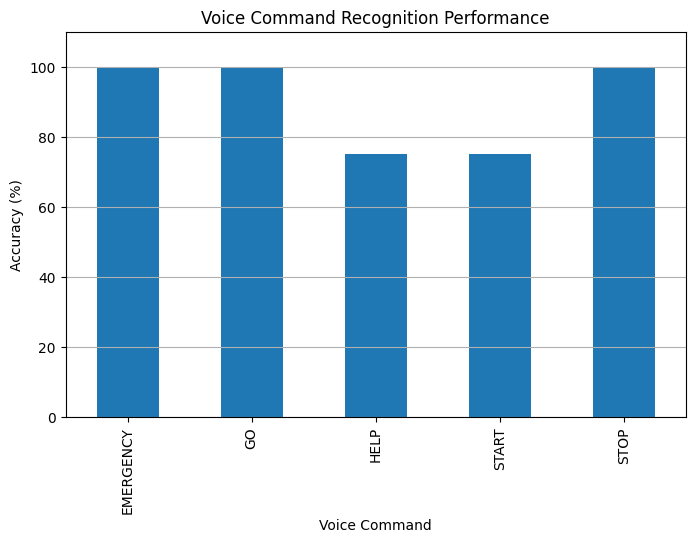

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

command_accuracy.plot(
    kind="bar"
)

plt.xlabel("Voice Command")
plt.ylabel("Accuracy (%)")
plt.title("Voice Command Recognition Performance")

plt.ylim(0, 110)
plt.grid(axis="y")

plt.show()

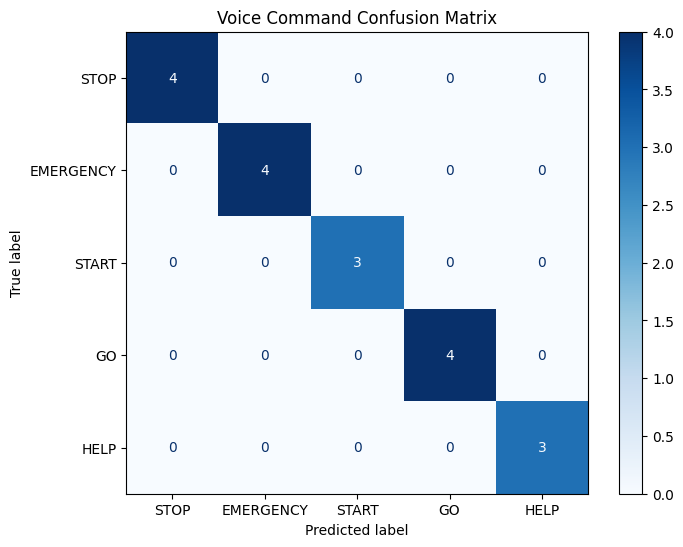

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

commands = [
    "STOP",
    "EMERGENCY",
    "START",
    "GO",
    "HELP"
]

cm = confusion_matrix(
    combined_df["Expected"],
    combined_df["Predicted"],
    labels=commands
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=commands
)

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title("Voice Command Confusion Matrix")
plt.show()

Overall Accuracy: 90.00%

Classification Report
              precision    recall  f1-score   support

        STOP     1.0000    1.0000    1.0000         4
   EMERGENCY     1.0000    1.0000    1.0000         4
       START     1.0000    0.7500    0.8571         4
          GO     1.0000    1.0000    1.0000         4
        HELP     1.0000    0.7500    0.8571         4

   micro avg     1.0000    0.9000    0.9474        20
   macro avg     1.0000    0.9000    0.9429        20
weighted avg     1.0000    0.9000    0.9429        20



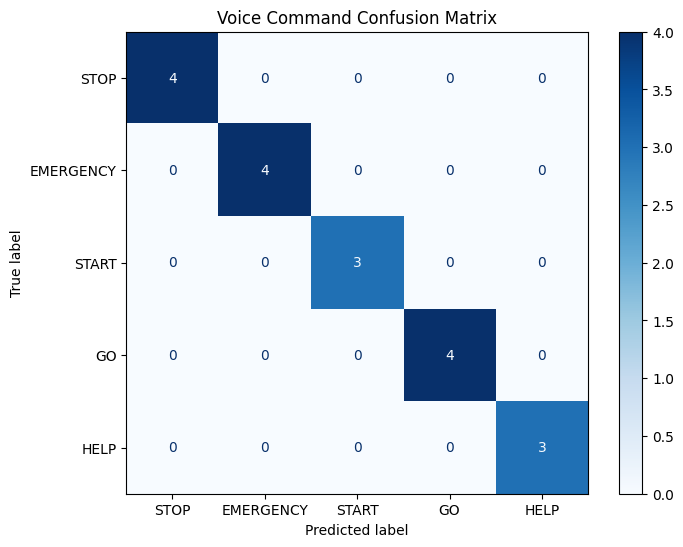

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

commands = [
    "STOP",
    "EMERGENCY",
    "START",
    "GO",
    "HELP"
]

# Overall accuracy
accuracy = (
    combined_df["Correct"].mean() * 100
)

print(f"Overall Accuracy: {accuracy:.2f}%")
print()

# Precision, Recall, F1
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        combined_df["Expected"],
        combined_df["Predicted"],
        labels=commands,
        zero_division=0,
        digits=4
    )
)

# Confusion Matrix
cm = confusion_matrix(
    combined_df["Expected"],
    combined_df["Predicted"],
    labels=commands
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=commands
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Voice Command Confusion Matrix")
plt.show()

In [ ]:
%%writefile voice_command_model.py

import re
import torch
from transformers import pipeline


# ============================================================
# VOICE COMMAND MODEL
# Smart Assistive Mobile Manipulator
# ============================================================

COMMANDS = [
    "STOP",
    "EMERGENCY",
    "START",
    "GO",
    "HELP"
]


# ------------------------------------------------------------
# Load Hugging Face Whisper
# ------------------------------------------------------------

device = 0 if torch.cuda.is_available() else -1

speech_to_text = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small",
    device=device,
    generate_kwargs={
        "language": "english",
        "task": "transcribe"
    }
)


# ------------------------------------------------------------
# Command Interpreter
# ------------------------------------------------------------

def safe_command_interpreter(text):

    text = str(text).lower().strip()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # EMERGENCY
    if (
        "emergency" in text
        or "urgent" in text
    ):
        return "EMERGENCY"

    # STOP
    if (
        "stop" in text
        or "halt" in text
        or "freeze" in text
    ):
        return "STOP"

    # START
    if (
        "start" in text
        or "resume" in text
    ):
        return "START"

    # GO
    if (
        text == "go"
        or "go forward" in text
        or "move forward" in text
        or text == "move"
        or "forward" in text
    ):
        return "GO"

    # HELP
    if (
        "help" in text
        or "assist" in text
        or "hint" in text
    ):
        return "HELP"

    return "UNKNOWN"


# ------------------------------------------------------------
# Complete voice-command prediction function
# ------------------------------------------------------------

def predict_command(audio_file):

    result = speech_to_text(audio_file)

    transcription = result["text"].strip()

    command = safe_command_interpreter(
        transcription
    )

    return {
        "transcription": transcription,
        "command": command
    }

Writing voice_command_model.py


In [ ]:
%%writefile requirements.txt

torch
transformers
accelerate
librosa
soundfile

Writing requirements.txt


In [ ]:
%%writefile test_voice_command.py

from voice_command_model import predict_command


audio_file = "test_audio.ogg"

result = predict_command(audio_file)

print("=" * 50)
print("VOICE COMMAND TEST")
print("=" * 50)

print("Transcription :", result["transcription"])
print("Command       :", result["command"])

Writing test_voice_command.py


In [ ]:
%%writefile README_VOICE_COMMANDS.md

# Smart Assistive Mobile Manipulator
## Voice Command Module

### Model

Hugging Face Whisper Small is used for automatic speech recognition.

Model:
openai/whisper-small

### Supported Commands

- STOP
- EMERGENCY
- START
- GO
- HELP

### Pipeline

Audio
→ Whisper Speech-to-Text
→ Command Interpreter
→ Robot Command

### Example

Input:
"Please stop the robot"

Whisper:
"Please stop the robot"

Command:
STOP

### Evaluation

The initial evaluation used 20 real audio samples.

Overall accuracy:
90%

The main error was associated with variation in the START command transcription.

### Hardware Integration

The software module can later be connected to:

Whisper
→ Command
→ Serial/Wi-Fi
→ Arduino Mega / ESP32
→ Robot controller

The physical emergency-stop button remains the primary hardware safety mechanism.

Writing README_VOICE_COMMANDS.md


In [ ]:
import os

for file in [
    "voice_command_model.py",
    "requirements.txt",
    "test_voice_command.py",
    "README_VOICE_COMMANDS.md"
]:
    print(file, "✓" if os.path.exists(file) else "✗")

voice_command_model.py ✓
requirements.txt ✓
test_voice_command.py ✓
README_VOICE_COMMANDS.md ✓


In [ ]:
from google.colab import files

files.download("voice_command_model.py")
files.download("requirements.txt")
files.download("test_voice_command.py")
files.download("README_VOICE_COMMANDS.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>